# importing data from mysql

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector

In [2]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="9511868679",
    database="ecommerce_analytics"
)

print("Connected Successfully")

Connected Successfully


In [3]:
users = pd.read_sql(
    "SELECT * FROM users",
    connection
)

C:\Users\badgu\AppData\Local\Temp\ipykernel_2568\1622260452.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  users = pd.read_sql(


In [4]:
products = pd.read_sql(
    "SELECT * FROM products",
    connection
)

C:\Users\badgu\AppData\Local\Temp\ipykernel_2568\2921944025.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products = pd.read_sql(


In [5]:
orders = pd.read_sql(
    "SELECT * FROM orders",
    connection
)

C:\Users\badgu\AppData\Local\Temp\ipykernel_2568\3367070390.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql(


In [6]:
order_items = pd.read_sql(
    "SELECT * FROM order_items",
    connection
)

C:\Users\badgu\AppData\Local\Temp\ipykernel_2568\3820138063.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql(


In [7]:
reviews = pd.read_sql(
    "SELECT * FROM reviews",
    connection
)

C:\Users\badgu\AppData\Local\Temp\ipykernel_2568\3847050644.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  reviews = pd.read_sql(


In [8]:
events = pd.read_sql(
    "SELECT * FROM events",
    connection
)

C:\Users\badgu\AppData\Local\Temp\ipykernel_2568\532060566.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  events = pd.read_sql(


# Data Overview

In [9]:
users.head()

,user_id,name,email,gender,city,signup_date
0,U000001,Angel Hill,donaldgarcia@example.net,Other,New Roberttown,2025-03-13
1,U000002,Jesse Guzman,jennifermiles@example.com,Male,South Bridget,2024-03-05
2,U000003,Adam Shaffer,jpeterson@example.org,Male,Curtisfurt,2025-07-07
3,U000004,Melanie Munoz,blairamanda@example.com,Other,New Kellystad,2024-03-07
4,U000005,Janet Williams,kendragalloway@example.org,Female,South Joshuastad,2025-01-29


In [10]:
orders.head()

,order_id,user_id,order_date,order_status,total_amount
0,O00000001,U009310,2025-09-09T14:52:37.292731,processing,689.66
1,O00000002,U003247,2025-04-15T01:18:27.193404,completed,1666.85
2,O00000003,U007252,2025-04-27T15:37:48.008624,processing,665.06
3,O00000004,U008986,2025-10-04T20:35:22.204857,cancelled,689.50
4,O00000005,U008537,2024-11-13T08:15:18.498252,cancelled,860.50


In [11]:
events.head()

,event_id,user_id,product_id,event_type,event_timestamp
0,E00000001,U009798,P001393,cart,2025-07-08T14:28:55.893919
1,E00000002,U005881,P000669,view,2025-10-19T23:00:44.067982
2,E00000003,U006348,P001404,view,2025-05-09T07:02:42.256662
3,E00000004,U002664,P000400,cart,2025-07-19T22:47:07.019634
4,E00000005,U005776,P000392,view,2024-10-24T10:20:33.602165


In [12]:
print("Users:", users.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Reviews:", reviews.shape)
print("Events:", events.shape)

Users: (10000, 6)
Products: (2000, 6)
Orders: (20000, 5)
Order Items: (43525, 7)
Reviews: (15000, 7)
Events: (80000, 5)


In [13]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

users["signup_date"] = pd.to_datetime(users["signup_date"])

events["event_timestamp"] = pd.to_datetime(events["event_timestamp"])

reviews["review_date"] = pd.to_datetime(reviews["review_date"])

In [14]:
orders["total_amount"].describe()

count    20000.000000
mean       595.933447
std        776.063336
min          1.110000
25%        111.355000
50%        308.195000
75%        768.195000
max       7950.740000
Name: total_amount, dtype: float64

In [15]:
products["category"].value_counts()

category
Clothing          213
Toys              213
Pet Supplies      212
Beauty            207
Electronics       203
Home & Kitchen    199
Books             194
Automotive        193
Groceries         183
Sports            183
Name: count, dtype: int64

In [16]:
events["event_type"].value_counts()

event_type
view        56013
cart        12035
wishlist     7946
purchase     4006
Name: count, dtype: int64

In [48]:
for name, df in {
    "Users": users,
    "Products": products,
    "Orders": orders,
    "Order Items": order_items,
    "Reviews": reviews,
    "Events": events
}.items():

    print("\n", name)
    print(df.columns.tolist())


 Users
['user_id', 'name', 'email', 'gender', 'city', 'signup_date']

 Products
['product_id', 'product_name', 'category', 'brand', 'price', 'rating']

 Orders
['order_id', 'user_id', 'order_date', 'order_status', 'total_amount']

 Order Items
['order_item_id', 'order_id', 'product_id', 'user_id', 'quantity', 'item_price', 'item_total']

 Reviews
['review_id', 'order_id', 'product_id', 'user_id', 'rating', 'review_text', 'review_date']

 Events
['event_id', 'user_id', 'product_id', 'event_type', 'event_timestamp']


In [18]:
summary = pd.DataFrame({
    "Table":[
        "Users",
        "Products",
        "Orders",
        "Order Items",
        "Reviews",
        "Events"
    ],
    "Rows":[
        len(users),
        len(products),
        len(orders),
        len(order_items),
        len(reviews),
        len(events)
    ]
})

summary

,Table,Rows
0,Users,10000
1,Products,2000
2,Orders,20000
3,Order Items,43525
4,Reviews,15000
5,Events,80000


# Business KPI Analysis

In [19]:
#Total Revenue

total_revenue = order_items["item_total"].sum()

print("Total Revenue:", round(total_revenue,2))

Total Revenue: 11918668.95


In [50]:
#Total Orders

total_orders = orders["order_id"].nunique()

print("Total Orders:", total_orders)

Total Orders: 20000


In [21]:
#Average Order Value (AOV)

aov = orders["total_amount"].mean()

print("Average Order Value:", round(aov,2))

Average Order Value: 595.93


In [22]:
#Total Customers

total_customers = users["user_id"].nunique()

print("Total Customers:", total_customers)

Total Customers: 10000


In [23]:
#Total Products

total_products = products["product_id"].nunique()

print("Total Products:", total_products)

Total Products: 2000


In [24]:
#Order Status Distribution

orders["order_status"].value_counts()

order_status
shipped       4113
returned      4066
completed     4021
cancelled     3920
processing    3880
Name: count, dtype: int64

In [25]:
#Event Engagement

events["event_type"].value_counts()

event_type
view        56013
cart        12035
wishlist     7946
purchase     4006
Name: count, dtype: int64

# Sales Analysis

In [26]:
#How is revenue changing over time

monthly_revenue = (
    orders
    .merge(order_items, on="order_id")
    .groupby(
        orders["order_date"].dt.to_period("M")
    )["item_total"]
    .sum()
)

monthly_revenue

order_date
2024-01    250551.44
2024-02    229520.49
2024-03    252772.01
2024-04    259803.34
2024-05    251614.98
2024-06    232408.83
2024-07    234320.51
2024-08    247644.32
2024-09    224973.64
2024-10    280498.59
2024-11    246393.01
2024-12    242942.40
2025-01    242173.02
2025-02    236708.16
2025-03    250287.91
2025-04    224853.95
2025-05    272900.30
2025-06    233763.87
2025-07    224867.10
2025-08    284945.55
2025-09    256106.48
2025-10    238355.77
2025-11    105609.02
Freq: M, Name: item_total, dtype: float64

In [27]:
monthly_revenue.index = monthly_revenue.index.astype(str)

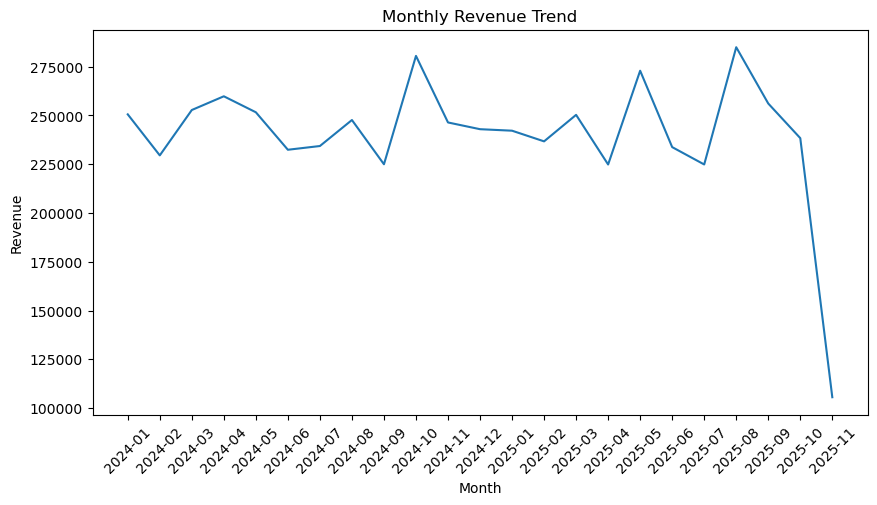

In [28]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values
)

plt.xticks(rotation=45)

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.title("Monthly Revenue Trend")

plt.show()

In [29]:
#Monthly Order Trend

monthly_orders = (
    orders
    .groupby(
        orders["order_date"].dt.to_period("M")
    )
    .size()
)

monthly_orders.index = monthly_orders.index.astype(str)

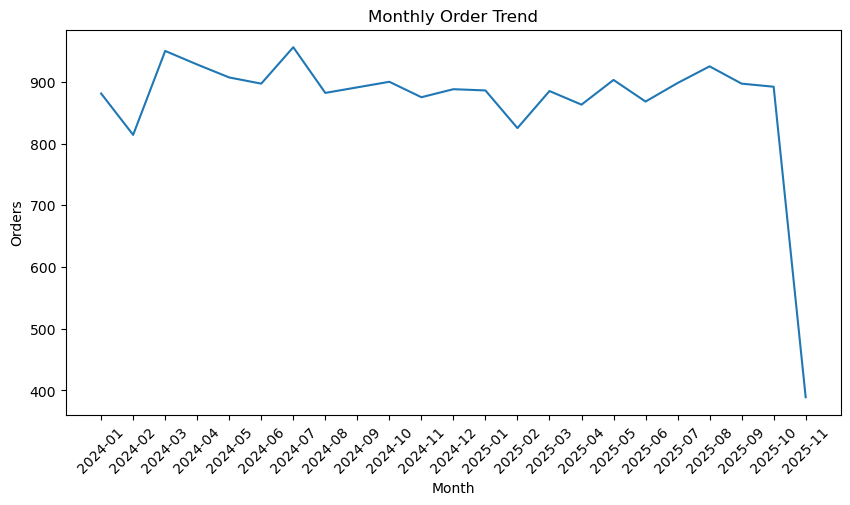

In [30]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values
)

plt.xticks(rotation=45)

plt.xlabel("Month")
plt.ylabel("Orders")

plt.title("Monthly Order Trend")

plt.show()

In [31]:
#Top 10 Products by Revenue

product_revenue = (
    order_items
    .merge(products, on="product_id")
    .groupby("product_name")["item_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

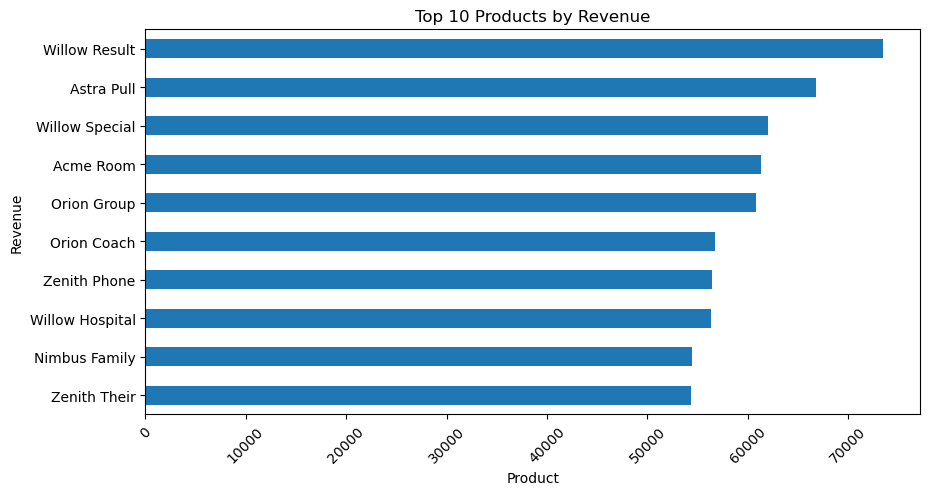

In [59]:
plt.figure(figsize=(10,5))

product_revenue.sort_values().plot(kind="barh")

plt.xlabel("Product")
plt.ylabel("Revenue")

plt.title("Top 10 Products by Revenue")

plt.xticks(rotation=45)

plt.show()

In [33]:
#Revenue by Category

category_revenue = (
    order_items
    .merge(products, on="product_id")
    .groupby("category")["item_total"]
    .sum()
    .sort_values(ascending=False)
)

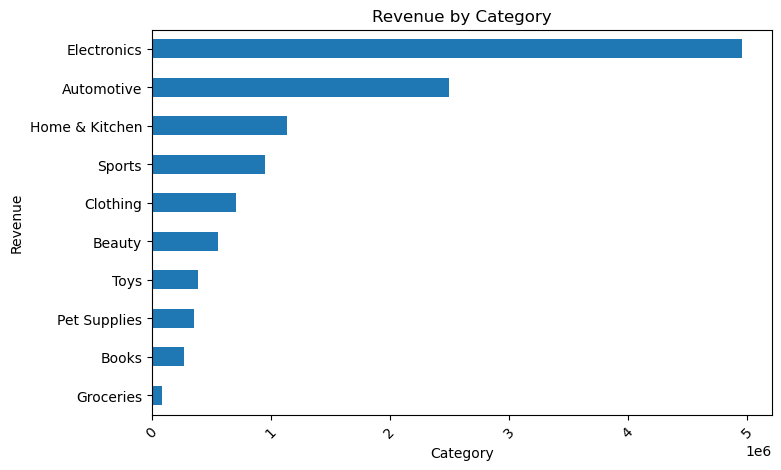

In [60]:
plt.figure(figsize=(8,5))

category_revenue.sort_values().plot(kind="barh")

plt.xlabel("Category")
plt.ylabel("Revenue")

plt.title("Revenue by Category")

plt.xticks(rotation=45)

plt.show()

In [35]:
#Order Status Distribution

order_status = orders["order_status"].value_counts()

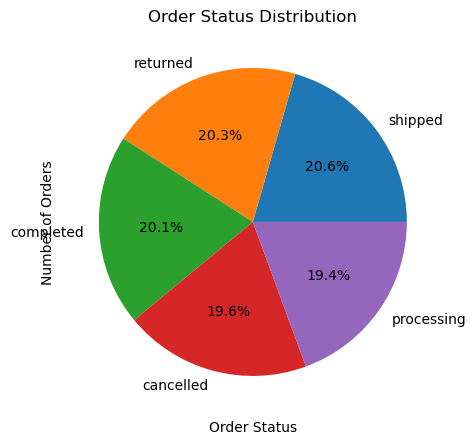

In [71]:
plt.figure(figsize=(7,5))

order_status.plot(kind="pie", autopct="%1.1f%%")

plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.title("Order Status Distribution")

plt.show()

# Customer Analysis EDA

In [37]:
#Top Customers by Spending

top_customers = (
    orders
    .merge(users, on="user_id")
    .groupby("name")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

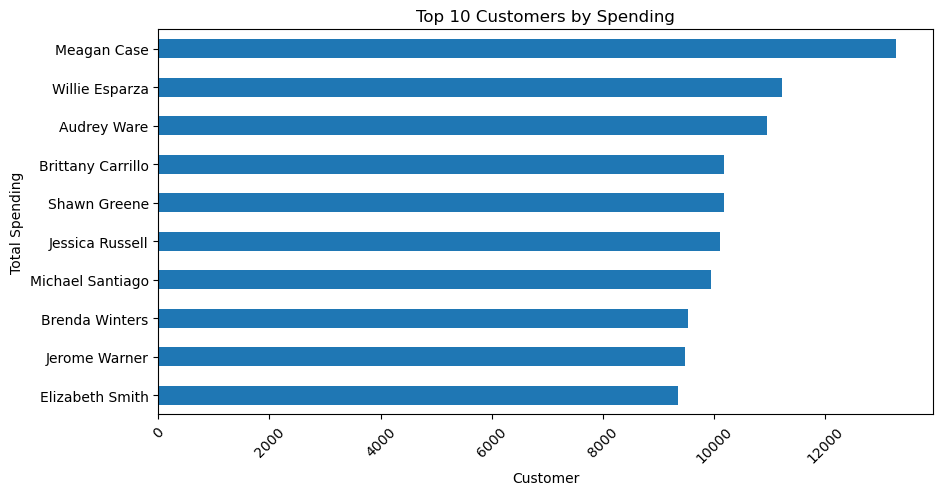

In [72]:
plt.figure(figsize=(10,5))

top_customers.sort_values().plot(kind="barh")

plt.xlabel("Customer")
plt.ylabel("Total Spending")

plt.title("Top 10 Customers by Spending")

plt.xticks(rotation=45)

plt.show()

In [39]:
#Orders by Customer

frequent_customers = (
    orders
    .merge(users, on="user_id")
    .groupby("name")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

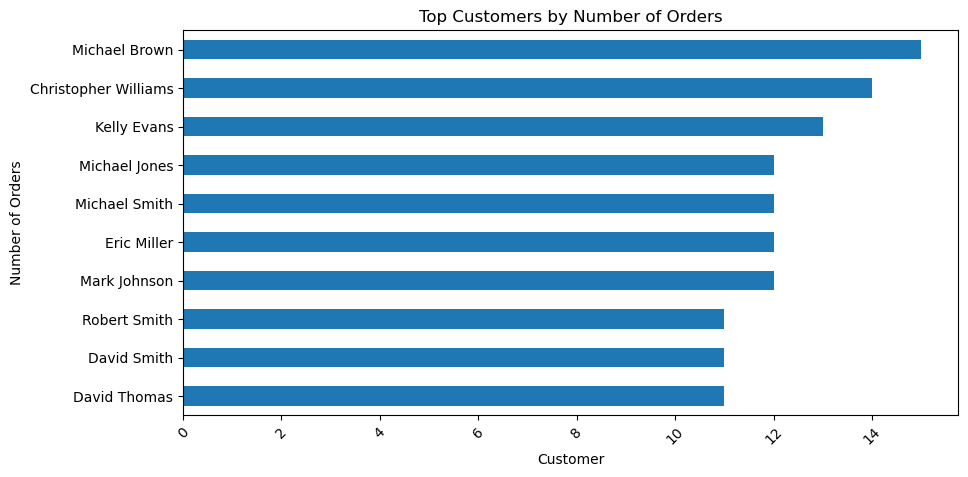

In [73]:
plt.figure(figsize=(10,5))

frequent_customers.sort_values().plot(kind="barh")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")

plt.title("Top Customers by Number of Orders")

plt.xticks(rotation=45)

plt.show()

In [41]:
# Revenue by City

city_revenue = (
    orders
    .merge(users, on="user_id")
    .groupby("city")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

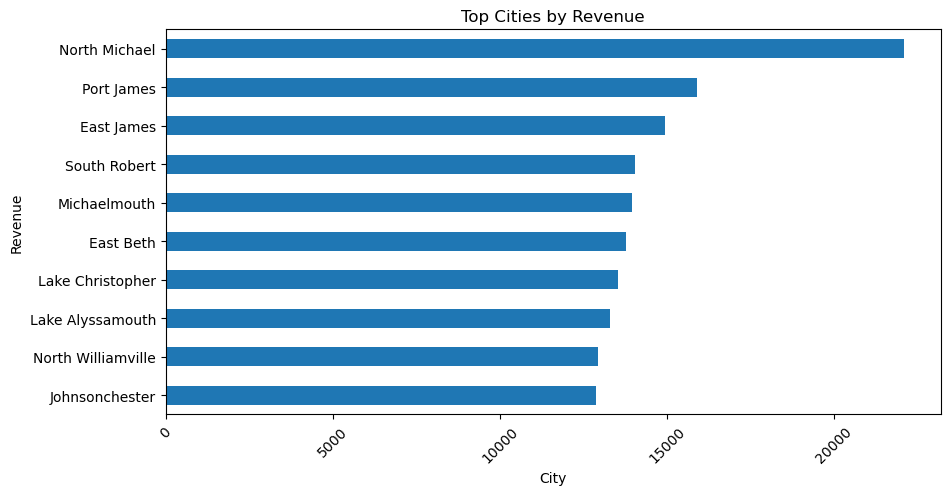

In [74]:
plt.figure(figsize=(10,5))

city_revenue.sort_values().plot(kind="barh")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.title("Top Cities by Revenue")

plt.xticks(rotation=45)

plt.show()

In [43]:
#Customer Distribution by City

city_customers = (
    users["city"]
    .value_counts()
    .head(10)
)

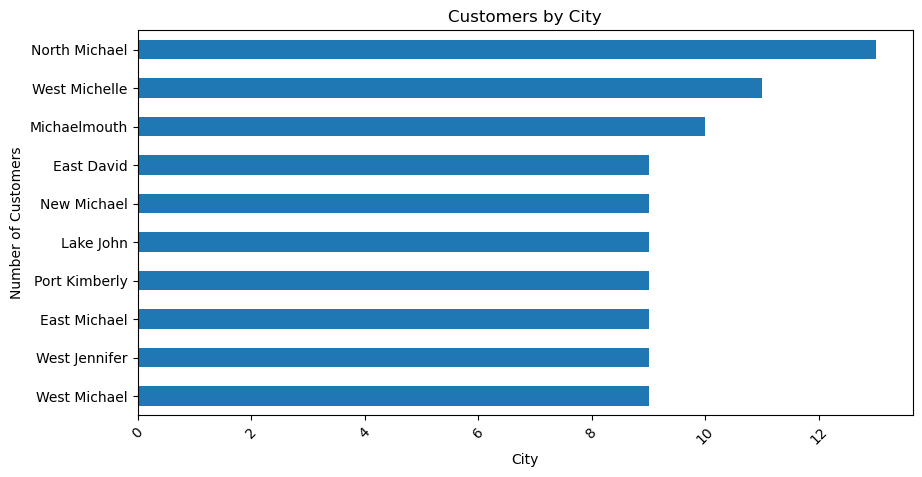

In [75]:
plt.figure(figsize=(10,5))

city_customers.sort_values().plot(kind="barh")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.title("Customers by City")

plt.xticks(rotation=45)

plt.show()

In [45]:
#Monthly New User Growth

monthly_users = (
    users
    .groupby(
        users["signup_date"].dt.to_period("M")
    )
    .size()
)

monthly_users.index = monthly_users.index.astype(str)

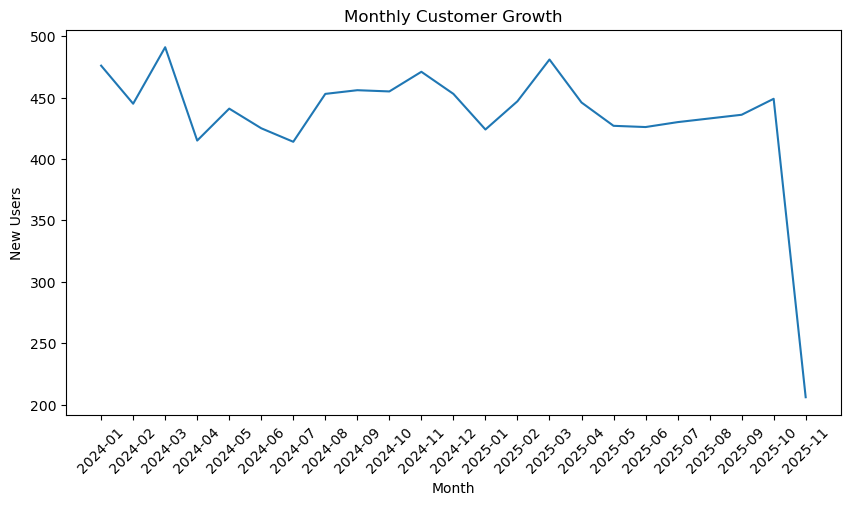

In [46]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_users.index,
    monthly_users.values
)

plt.xticks(rotation=45)

plt.xlabel("Month")
plt.ylabel("New Users")

plt.title("Monthly Customer Growth")

plt.show()

# Product Analysis EDA

In [51]:
# Top Products by Sales Quantity

top_quantity_products = (
    order_items
    .merge(products, on="product_id")
    .groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

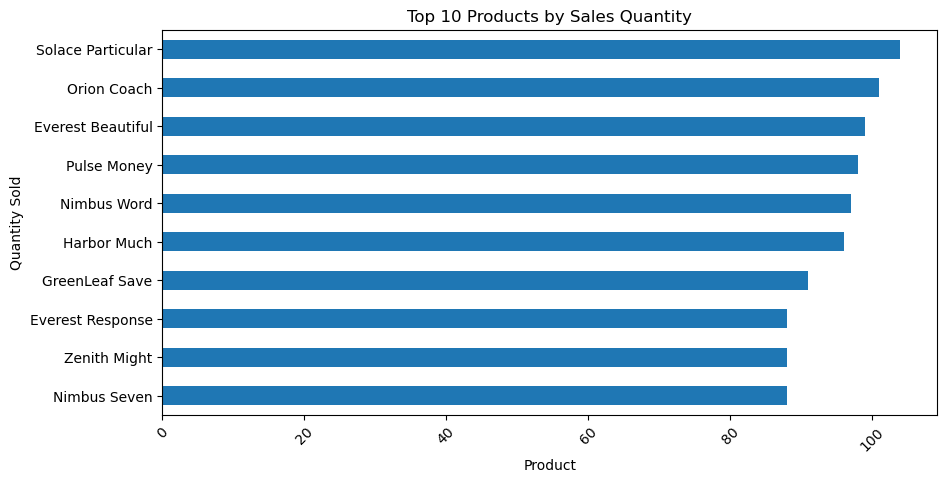

In [76]:
plt.figure(figsize=(10,5))

top_quantity_products.sort_values().plot(kind="barh")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.title("Top 10 Products by Sales Quantity")

plt.xticks(rotation=45)

plt.show()

In [53]:
# Top Products by Revenue

top_product_revenue = (
    order_items
    .merge(products, on="product_id")
    .groupby("product_name")["item_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

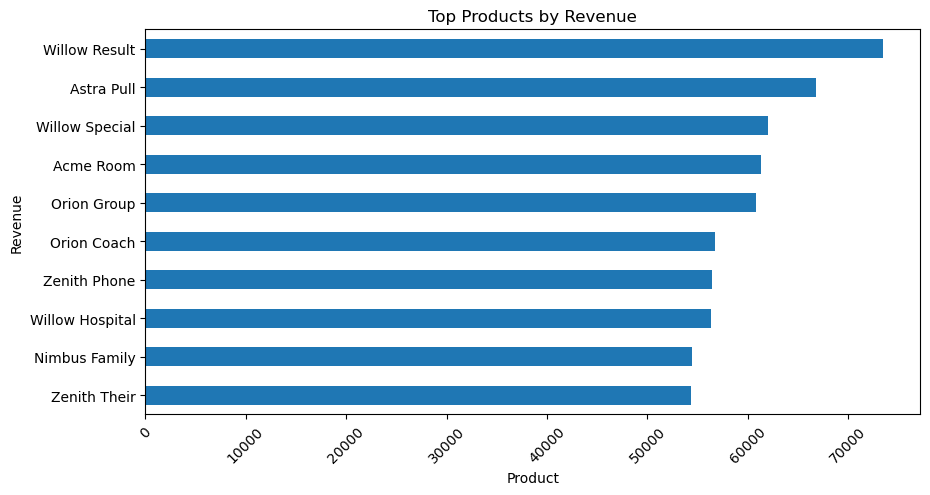

In [77]:
plt.figure(figsize=(10,5))

top_product_revenue.sort_values().plot(kind="barh")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.title("Top Products by Revenue")

plt.xticks(rotation=45)

plt.show()

In [55]:
#Category Performance

category_sales = (
    order_items
    .merge(products, on="product_id")
    .groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

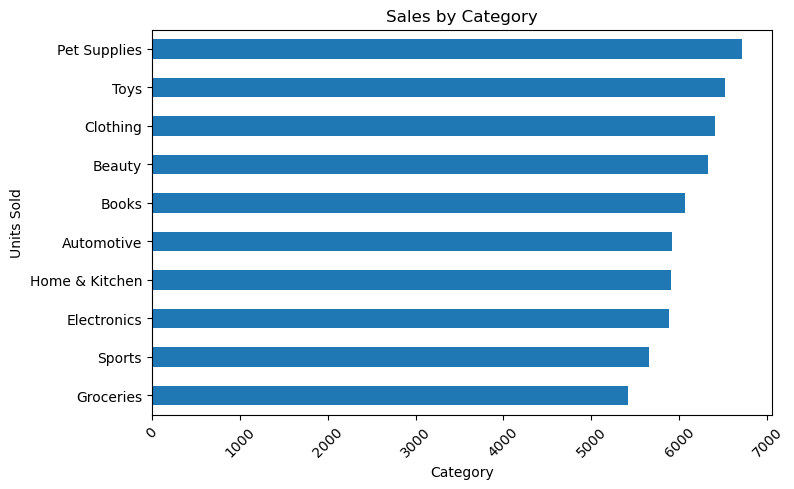

In [78]:
plt.figure(figsize=(8,5))

category_sales.sort_values().plot(kind="barh")
plt.xlabel("Category")
plt.ylabel("Units Sold")

plt.title("Sales by Category")

plt.xticks(rotation=45)

plt.show()

In [57]:
# Product Rating Distribution

rating_distribution = reviews["rating"].value_counts().sort_index()

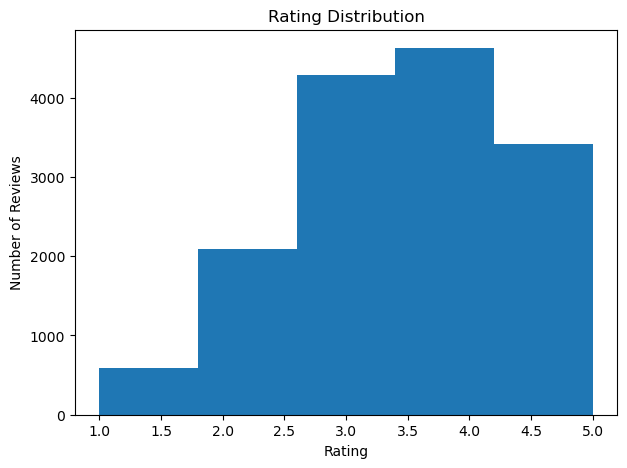

In [90]:
plt.figure(figsize=(7,5))

plt.hist(
    reviews["rating"],
    bins=5
)

plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.title("Rating Distribution")

plt.show()

In [98]:
#Most Reviewed Products

most_reviewed = (
    reviews
    .merge(products, on="product_id")
    .groupby("product_name")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

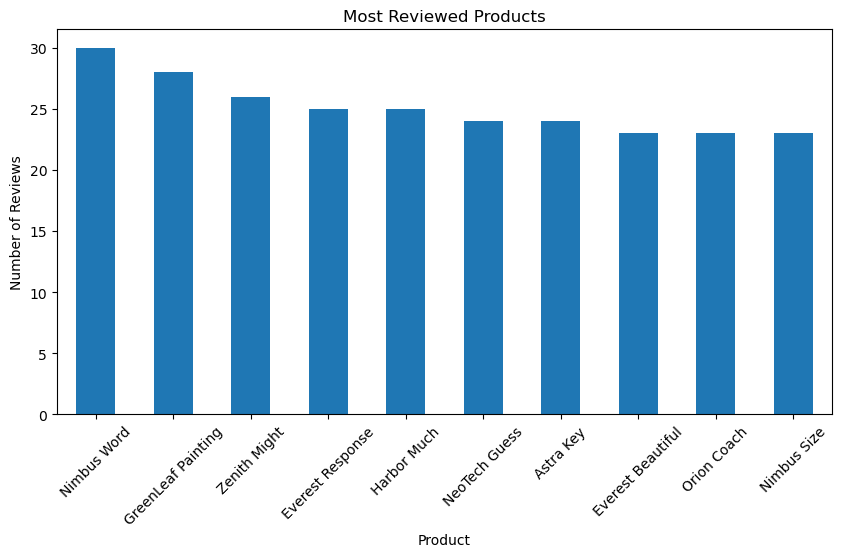

In [99]:
plt.figure(figsize=(10,5))

most_reviewed.plot(kind="bar")

plt.xlabel("Product")

plt.ylabel("Number of Reviews")

plt.title("Most Reviewed Products")

plt.xticks(rotation=45)

plt.show()

# User Behavior Analysis EDA

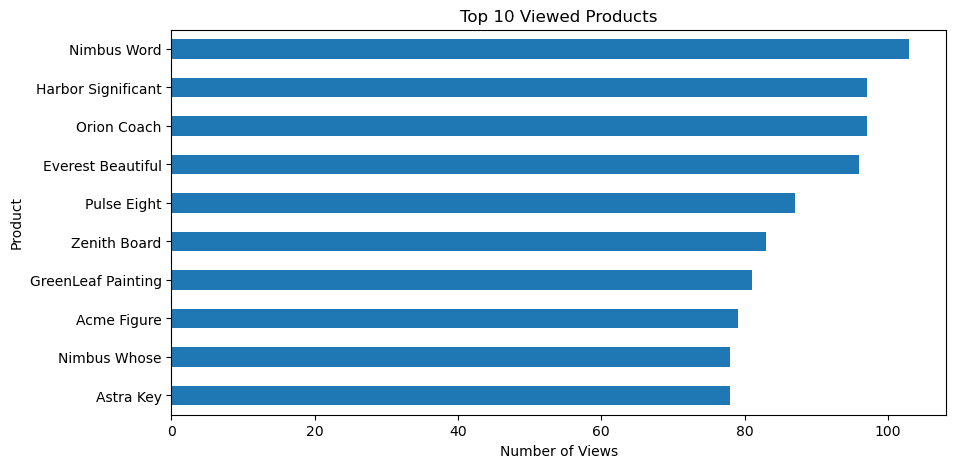

In [92]:
#Top Viewed Products

top_viewed_products = (
    events[events["event_type"] == "view"]
    .merge(products, on="product_id")
    .groupby("product_name")
    .size()
    .sort_values(ascending=False)
    .head(10)
)


plt.figure(figsize=(10,5))

top_viewed_products.sort_values().plot(kind="barh")

plt.xlabel("Number of Views")
plt.ylabel("Product")

plt.title("Top 10 Viewed Products")

plt.show()

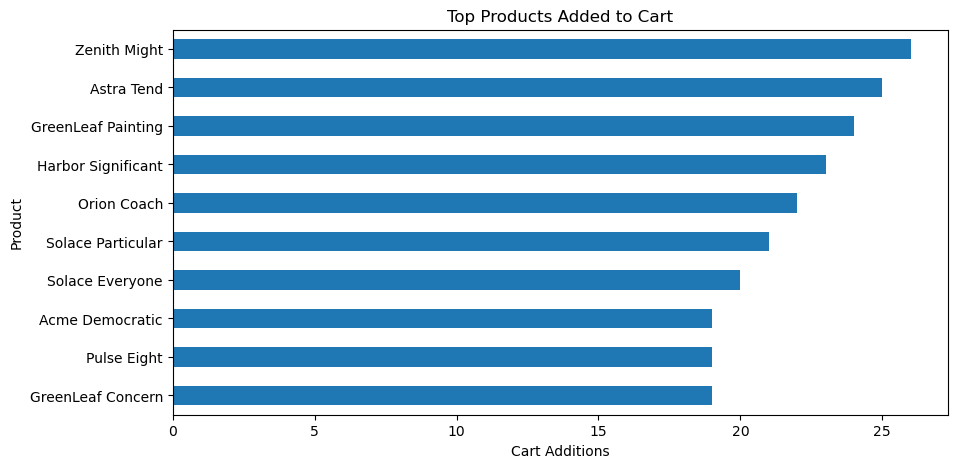

In [93]:
#. Products Added to Cart Most Frequently


top_cart_products = (
    events[events["event_type"] == "cart"]
    .merge(products, on="product_id")
    .groupby("product_name")
    .size()
    .sort_values(ascending=False)
    .head(10)
)


plt.figure(figsize=(10,5))

top_cart_products.sort_values().plot(kind="barh")

plt.xlabel("Cart Additions")
plt.ylabel("Product")

plt.title("Top Products Added to Cart")

plt.show()

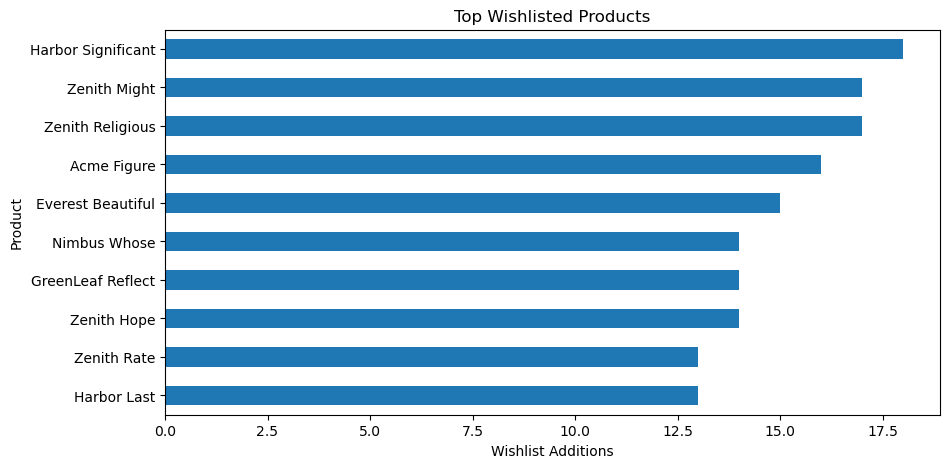

In [94]:
#Products Added to Wishlist Most Frequently

top_wishlist_products = (
    events[events["event_type"] == "wishlist"]
    .merge(products, on="product_id")
    .groupby("product_name")
    .size()
    .sort_values(ascending=False)
    .head(10)
)


plt.figure(figsize=(10,5))

top_wishlist_products.sort_values().plot(kind="barh")

plt.xlabel("Wishlist Additions")
plt.ylabel("Product")

plt.title("Top Wishlisted Products")

plt.show()

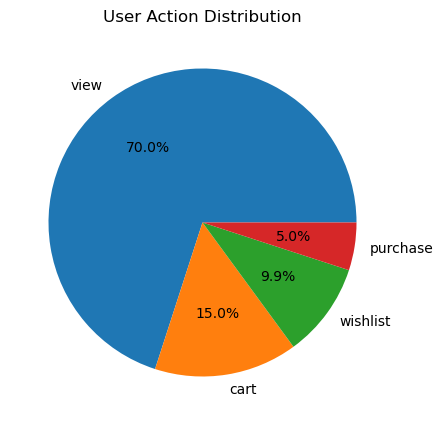

In [95]:
#User Action Distribution


event_distribution = events["event_type"].value_counts()


plt.figure(figsize=(7,5))

event_distribution.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("User Action Distribution")

plt.ylabel("")

plt.show()

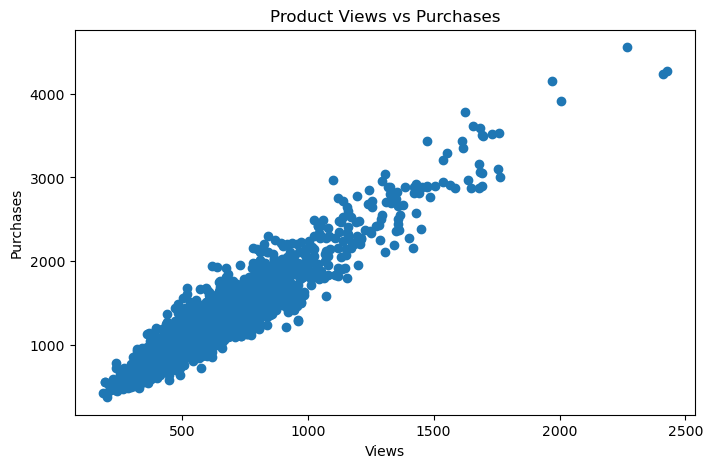

In [96]:
#High Views vs Low Purchases

product_engagement = (
    products
    .merge(events, on="product_id", how="left")
    .merge(order_items, on="product_id", how="left")
    .groupby("product_name")
    .agg(
        total_views=("event_type",
                     lambda x: (x=="view").sum()),

        total_purchases=("quantity","sum")
    )
    .fillna(0)
)


plt.figure(figsize=(8,5))

plt.scatter(
    product_engagement["total_views"],
    product_engagement["total_purchases"]
)

plt.xlabel("Views")

plt.ylabel("Purchases")

plt.title("Product Views vs Purchases")

plt.show()

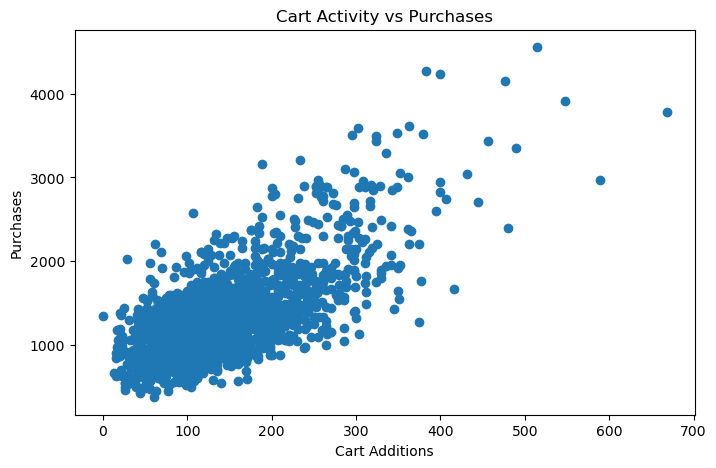

In [97]:
#High Cart Activity vs Low Purchases

cart_purchase = (
    products
    .merge(events, on="product_id", how="left")
    .merge(order_items, on="product_id", how="left")
    .groupby("product_name")
    .agg(
        total_cart=("event_type",
                    lambda x: (x=="cart").sum()),

        total_purchases=("quantity","sum")
    )
    .fillna(0)
)


plt.figure(figsize=(8,5))

plt.scatter(
    cart_purchase["total_cart"],
    cart_purchase["total_purchases"]
)

plt.xlabel("Cart Additions")

plt.ylabel("Purchases")

plt.title("Cart Activity vs Purchases")

plt.show()